## Emotion Classification with RNNs, LSTMs & GRUs

classifying text into 6 emotions (sadness, joy, love, anger, fear, surprise) by comparing plain recurrent models before building an advanced Bidirectional GRU

## 1 --> Required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
# dataset load krvaegi

## 2 --> load dataset

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
label_name = emotion_dataset['train'].features['label'].names
label_name

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [4]:
train_label

Column([0, 0, 3, 2, 3])

In [5]:
df_train = pd.DataFrame(
    {
        'text' : train_text,
        #mapping krege train_label or test_label ko by list comprehension
        'label': [label_name[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text' : test_text,
        'label': [label_name[i] for i in test_label]
    }
)


In [6]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [7]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [8]:
df_train.isnull().sum()




,0
text,0
label,0


In [9]:
df_test.isnull().sum()

,0
text,0
label,0


## 3 --> EDA

In [10]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


<Axes: xlabel='label', ylabel='count'>

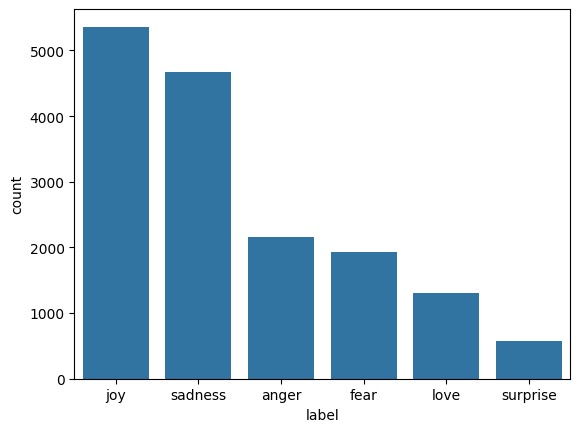

In [11]:
sns.countplot(x = 'label', data = df_train, order =df_train['label'].value_counts().index)

## 4 --> Data Preprocessing - by NLP
words ko no m convert kr diyaa
words with less fequency --> Higher no
#
words with more fequency --> lower no

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words = max_words, oov_token = '<unk>')
# oov_token = '<unk>' means jo word training k time vocab m nhi aya usko model as a unknwn mark krde ga

tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence  = tokenizer.texts_to_sequences(df_test['text'])

# Padding isiliye ki taki rnn m same length off input jaye nhi to hrr text k liye alag alag jaegi
padded_train_sequence = pad_sequences(train_sequence, maxlen= 50,padding = 'post', truncating = 'post')
padded_test_sequence = pad_sequences(test_sequence, maxlen= 50,padding = 'post', truncating = 'post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentences Length: {padded_train_sequence.shape[1]}")


Vocabulary Size: 15213
Max Sentences Length: 50


## 5 --> shared Training Utilities  
compute Balanced class weights to handle dataset skew and setup early stopping

In [13]:
from sklearn.utils import class_weight

class_weight = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weight_dict = dict(enumerate(class_weight))

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3, # kitne epoches tk wait kre
    restore_best_weights = True

)

## 6 --> first plain foundational model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    SimpleRNN(units = 128, return_sequences = True),
    Dropout(0.5), # Rnn k ander hidden layer hoti h agar jada hl hogi to model overfit kr jaega to 50% ko remove kredega
    SimpleRNN(units = 128),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax') # output layer
])

# big data h to 2 rnn block

rnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
rnn_model.fit(
    padded_train_sequence, #input
    train_labels, #output
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"Rnn Loss: {rnn_loss}")
print(f"Rnn Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.1624 - loss: 2.0162 - val_accuracy: 0.1045 - val_loss: 1.7878
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.1434 - loss: 1.8926 - val_accuracy: 0.0770 - val_loss: 1.8233
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1510 - loss: 1.8357 - val_accuracy: 0.2015 - val_loss: 1.8075
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1373 - loss: 1.8168 - val_accuracy: 0.3195 - val_loss: 1.7625
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1476 - loss: 1.8131 - val_accuracy: 0.0755 - val_loss: 1.7487
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1484 - loss: 1.8145 - val_accuracy: 0.0405 - val_loss: 1.8214
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1420 - loss: 1.8110 - val_accuracy: 0.0610 - val_loss: 1.9002
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1505 - loss: 1.8118 - val_acc

## Model 2 --> Standard LSTM

In [17]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    LSTM(units = 128, return_sequences = True),
    Dropout(0.5), # LSTM k ander hidden layer hoti h agar jada hl hogi to model overfit kr jaega to 50% ko remove kredega
    LSTM(units = 128),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax') # output layer
])

lstm_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [18]:
lstm_model.fit(
    padded_train_sequence, #input
    train_labels, #output
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.1629 - loss: 1.7949 - val_accuracy: 0.0800 - val_loss: 1.8122
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1303 - loss: 1.7938 - val_accuracy: 0.0810 - val_loss: 1.7924
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1700 - loss: 1.7696 - val_accuracy: 0.2085 - val_loss: 1.7483
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0800 - loss: 1.8122
LSTM Loss: 1.8122193813323975
LSTM Accuracy: 0.07999999821186066


## Model 3 --> Standard GRU

In [19]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    GRU(units = 128, return_sequences = True),
    Dropout(0.5), # LSTM k ander hidden layer hoti h agar jada hl hogi to model overfit kr jaega to 50% ko remove kredega
    GRU(units = 128),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax') # output layer
])

gru_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [20]:
gru_model.fit(
    padded_train_sequence, #input
    train_labels, #output
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.1363 - loss: 1.7955 - val_accuracy: 0.0335 - val_loss: 1.9092
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1446 - loss: 1.7958 - val_accuracy: 0.3475 - val_loss: 1.7652
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1676 - loss: 1.7938 - val_accuracy: 0.0335 - val_loss: 1.8167
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0335 - loss: 1.9092
GRU Loss: 1.9091753959655762
GRU Accuracy: 0.03350000083446503


## Ranking and selection

In [21]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', "GRU"],
    'Test Loss' : [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy' : [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by = 'Test Accuracy', ascending= False)
result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.736382,0.3235
1,LSTM,1.812219,0.0800
2,GRU,1.909175,0.0335


## 7 --> Phase 2 - Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization


In [22]:
# Bidirectional GRU ye dono side se sentence dekhega - (left to right + right to left)
from tensorflow.keras.layers import Bidirectional

BIGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=50, mask_zero=True), # mask_zeros jo extra zeros add ki thi usko mask krne k liye taki model overfit na ho
    Bidirectional(GRU(128, return_sequences=True, recurrent_dropout=0.2)),
    Dropout(0.4),
    Bidirectional(GRU(64, recurrent_dropout=0.2)),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

BIGRU.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
    )

BIGRU.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train & Evaluate Advanced Bidirectional GRU

In [23]:
BIGRU.fit(
    padded_train_sequence, #input
    train_labels, #output
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 196s 374ms/step - accuracy: 0.6558 - loss: 0.8764 - val_accuracy: 0.9010 - val_loss: 0.2891
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 184s 368ms/step - accuracy: 0.9261 - loss: 0.1923 - val_accuracy: 0.9170 - val_loss: 0.2042
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 185s 370ms/step - accuracy: 0.9509 - loss: 0.1218 - val_accuracy: 0.9130 - val_loss: 0.2481
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 188s 375ms/step - accuracy: 0.9686 - loss: 0.0848 - val_accuracy: 0.9125 - val_loss: 0.2445
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 198s 368ms/step - accuracy: 0.9730 - loss: 0.0724 - val_accuracy: 0.9155 - val_loss: 0.2601


In [24]:
BIGRU_loss, BIGRU_accuracy = BIGRU.evaluate(padded_test_sequence, test_labels)
print(f"BIGRU Loss: {BIGRU_loss}")
print(f"BIGRU Accuracy: {BIGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - accuracy: 0.9170 - loss: 0.2042
BIGRU Loss: 0.20418232679367065
BIGRU Accuracy: 0.9169999957084656


## 8 --> Overall Evaluation & Bias Analysis
test metrices, plot raw & normalized confusion matrices and analyze bias

Final Model confusion Matrices(Raw Counts & Normalized %)

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step


<Axes: >

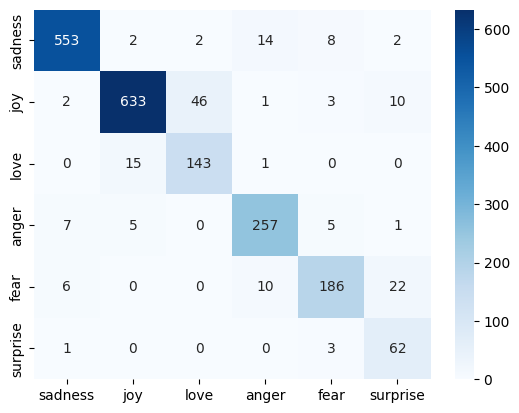

In [25]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BIGRU.predict(padded_test_sequence),axis = 1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions), annot = True, fmt = 'd', cmap = 'Blues',xticklabels = label_name, yticklabels = label_name)
#

## 9 --> Final Predictions
test the model on unseen sample sentences

In [26]:
label_name

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [27]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BIGRU.predict(sample_padded_sequences), axis=1)
sample_predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


array([5, 0, 3, 4, 5])

In [28]:
sample_texts = [
    "I am very happy today.",
    "I feel very sad today.",
    "I am very angry right now.",
    "I am scared of the dark.",
    "I am afraid of this place.",
    "I love my family so much.",
    "I am surprised by this news.",
    "I feel great today.",
    "I am feeling lonely.",
    "I am so angry with him.",
    "I am scared right now.",
    "I love this so much.",
    "I am really happy.",
    "I feel sad and tired.",
    "I am shocked by the news."
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BIGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion : {label_name[sample_predictions[i]]}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Text: I am very happy today.
Predicted Emotion : joy
Text: I feel very sad today.
Predicted Emotion : sadness
Text: I am very angry right now.
Predicted Emotion : anger
Text: I am scared of the dark.
Predicted Emotion : fear
Text: I am afraid of this place.
Predicted Emotion : fear
Text: I love my family so much.
Predicted Emotion : joy
Text: I am surprised by this news.
Predicted Emotion : surprise
Text: I feel great today.
Predicted Emotion : sadness
Text: I am feeling lonely.
Predicted Emotion : sadness
Text: I am so angry with him.
Predicted Emotion : anger
Text: I am scared right now.
Predicted Emotion : fear
Text: I love this so much.
Predicted Emotion : joy
Text: I am really happy.
Predicted Emotion : joy
Text: I feel sad and tired.
Predicted Emotion : sadness
Text: I am shocked by the news.
Predicted Emotion : surprise


## 10 --> saving Model & tokenizer

In [29]:
import os
import pickle

model_dir = 'Models'
os.makedirs(model_dir, exist_ok = True) # Folder h jiske ander model ane vala h

# Save our BIGRU Model
BIGRU.save(os.path.join(model_dir,'BIGRU_model.keras'))

# Save the tokenizer Model
with open(os.path.join(model_dir,'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)
